<a href="https://colab.research.google.com/github/Paresh935/AML-Lab/blob/main/data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load the standard Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)    #df and pd is object

In [ ]:
#first few records
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
#number of rows and column
print("shape",df.shape)

shape (891, 12)


In [ ]:
#column name
print("\ncolumns")
print(df.columns.tolist())


columns
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [ ]:
#data types
print("\ndatatype")
print(df.dtypes)


datatype
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
#statistical summary
print(df.describe())
print("\nstatistical summary")

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

statistical summary


In [ ]:
#categorial column
print("\ncategorial column")
print(df.select_dtypes(include='object').columns.tolist())


categorial column
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [ ]:
#numerical column
print("numerical column")
print(df.select_dtypes(include=np.number).columns.tolist)

numerical column
<bound method IndexOpsMixin.tolist of Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')>


In [ ]:
missing=df.isnull().sum()
print(missing)

missing_percent=(df.isnull().sum()/len(df))*100

missing_table=pd.DataFrame({
    "Missing Count":missing,
    "Missing Percntage":missing_percent
})

print(missing_table)



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
             Missing Count  Missing Percntage
PassengerId              0           0.000000
Survived                 0           0.000000
Pclass                   0           0.000000
Name                     0           0.000000
Sex                      0           0.000000
Age                    177          19.865320
SibSp                    0           0.000000
Parch                    0           0.000000
Ticket                   0           0.000000
Fare                     0           0.000000
Cabin                  687          77.104377
Embarked                 2           0.224467


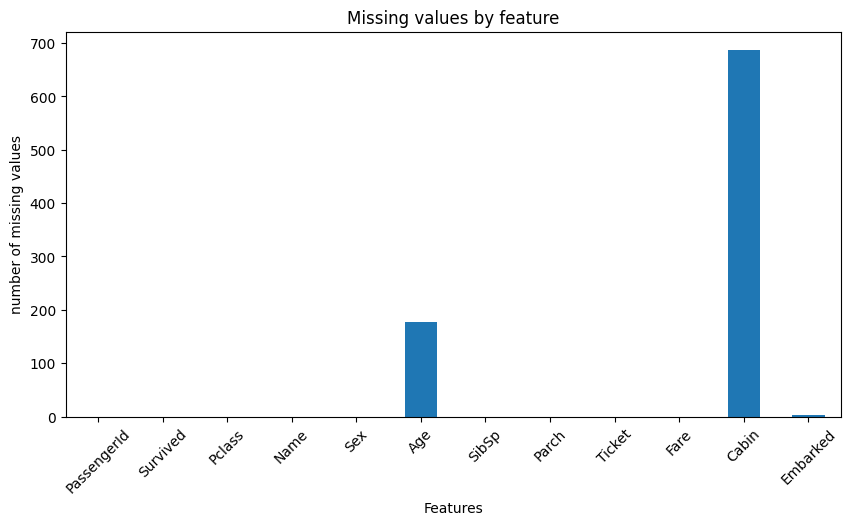

duplicate rows 0


In [ ]:
plt.figure(figsize=(10,5))
df.isnull().sum().plot(kind='bar')
plt.title("Missing values by feature")
plt.xlabel("Features")
plt.ylabel("number of missing values")
plt.xticks(rotation=45)
plt.show()

print("duplicate rows",df.duplicated().sum())

In [ ]:
#mean  average of available nummerical Values (sensitive for extreme values)
#median moddle value after sorting(outlinear are present)
#mode most frequently occuring value(categorical varibles)


In [ ]:
#replace missing values by mean
df_mean =df.copy()
mean_age=df_mean['Age'].mean()
df_mean['Age']=df_mean['Age'].fillna(mean_age)

print("remaining missing age values:",df_mean['Age'].isnull().sum())

#replace missing values by median
df_median =df.copy()
median_age=df_median['Age'].median()
df_median['Age']=df_median['Age'].fillna(median_age)

print("Remaning missing Age values")

print("mean age:",df['Age'].mean())
print("median age",df['Age'].median())

#replace missing values by mode-categorical data
df_mode=df.copy()
mode_emabarked=df_mode['Embarked'].mode()[0]
df_mode['Embarked']=df_mode['Embarked'].fillna(mode_emabarked)

print("remaing missing embarked values",
      df_mode['Embarked'].isnull().sum())

remaining missing age values: 0
Remaning missing Age values
mean age: 29.69911764705882
median age 28.0
remaing missing embarked values 0


In [ ]:
#Encoding technics
#labele encoding: assigns an integer to each cateory
#one hot encodiing: creats binary column for each category

In [ ]:
#encoding -one-hot

print(df[['Sex','Embarked']].head(10))

from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded = encoder.fit_transform(df[['Sex',"Embarked"]])

encoded_df=pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Sex','Embarked'])

)
print(encoded_df.head())


#Encoding - Label
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Survived_encoded'] = le.fit_transform(df['Survived'])

print(df[['Survived','Survived_encoded']].head())

      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S
5    male        Q
6    male        S
7    male        S
8  female        S
9  female        C
   Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Embarked_nan
0         0.0       1.0         0.0         0.0         1.0           0.0
1         1.0       0.0         1.0         0.0         0.0           0.0
2         1.0       0.0         0.0         0.0         1.0           0.0
3         1.0       0.0         0.0         0.0         1.0           0.0
4         0.0       1.0         0.0         0.0         1.0           0.0
   Survived  Survived_encoded
0         0                 0
1         1                 1
2         1                 1
3         1                 1
4         0                 0


In [ ]:
#feature scaling
#features can have different numerical ranges
#large scale features may dominate distance or gradient based algorithm


#min-max scaling converts values to a specified range commonly 0-1
#uses minimum and maxminum values


In [ ]:
#why use pipeline?
#reduuce repetative code
#helps to prevent data lekage




In [ ]:
#raw dataset->explore->identify problem->handle missing values->encode categories->scale features->train/test split->preprocessed

#why is median sometimes prefered over mean
#why should we not blindly use label encoding for nominal variables
#why should scaling fiting on testing data only?



In [ ]:
#min-max scaling
features=df[['Age','Fare']].dropna()
print(features.describe())
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
scaled_minmax=minmax.fit_transform(features)

minmax_df=pd.DataFrame(
    scaled_minmax,
    columns=['Age','Fare']
)

print(minmax_df.head())

#Standardisation
from sklearn.preprocessing import StandardScaler
standard = StandardScaler()
scaled_standard= standard.fit_transform(features)

standard_df =pd.DataFrame(
    scaled_standard,
    columns=['Age','Fare']
)
print(standard_df.head())


              Age        Fare
count  714.000000  714.000000
mean    29.699118   34.694514
std     14.526497   52.918930
min      0.420000    0.000000
25%     20.125000    8.050000
50%     28.000000   15.741700
75%     38.000000   33.375000
max     80.000000  512.329200
        Age      Fare
0  0.271174  0.014151
1  0.472229  0.139136
2  0.321438  0.015469
3  0.434531  0.103644
4  0.434531  0.015713
        Age      Fare
0 -0.530377 -0.518978
1  0.571831  0.691897
2 -0.254825 -0.506214
3  0.365167  0.348049
4  0.365167 -0.503850
